### Analyzing the NFL Combine's Influence on Draft Position and Team Performance

#### Team Name: Roger Goodell Non-Fanclub

#### Team Member Names and PIDS:
- Michael Holman - mholman2003
- Joey Kozohar - joeykozohar
- Jason Bruno Terceros - jasonb19
- Christopher Parker - cdparker
- Steven Bottone - stevenb7

### Project Introduction
#### Initial description of the project topic:
The NFL Combine is an annual showcase where college football players perform various physical tests in front of NFL scouts. Athletes hope through the combine, they can increase their draft status in hopes of getting drafted into the NFL. Our research project will be two-fold. First, we plan on looking to find connections between the NFL combine and the NFL draft. We hope to look at multiple factors from the combine and see what most influences a player's draft position. Secondly, for teams that obtain the first overall selection in a draft, we plan to find how that player changes the attendance, and performance for the team. 

#### Potential research questions you plan to address:
- Which NFL combine metric is most correlated with draft position?
- How does NFL combine performance impact draft position?
- Teams with first overall pick, how does their record in the upcoming season compare to the prior season? 
- Does getting the first overall pick impact stadium attendance for the upcoming season?

#### Description of potential source data that would be relevant:
The data comes from a recommended and trusted site. On kaggle we were able to find different data sets that we believe to be useful for our research questions and evaluations. We began at looking for data about the draft. We found some history of the NFL draft that we thought could be useful for showing trends over the years for position, ranking, etc. We then wanted to find more specified data that would relate to combine outcomes. We used this as our primary data source to evalute our players to their respective outcomes on combine performance. Lastly, we found some interesting data on hall of fame and attendance that we will plan to use for future analytical purposes. We have provided links to our data down below.
- NFL Combine: https://www.kaggle.com/datasets/redlineracer/nfl-combine-performance-data-2009-2019
- NFL Draft History https://www.kaggle.com/datasets/dubradave/nfl-draft-history-1990-present
- Hall of Fame analysis https://www.kaggle.com/code/mattop/nfl-football-hall-of-fame-players-analysis
- NFL stadium attendance https://www.kaggle.com/datasets/sujaykapadnis/nfl-stadium-attendance-dataset


### Part 1: Combine Performance and Draft Position
### Procedure
Our initial conversation for this topic arose when we started to talk about the current combine statistics. We were impressed with some performances and were curious to see how these outstanding players, that perform well in the combine, do in the NFL draft. 
We began to look through the list of acceptable resources to find datasets for our intial assumption. Out of all the sites that we were provided only one had information on what we were looking for. It did not provide the answer to the questions we had but here is where we began to analyze our data. 
Our initial download consisted of reviewing our raw data to determine what we were looking at and where to start. We began with the NFL Combine - Performance and started to clean our data. There were a few categories in our dataset that we found to be irrelevant to what we were looking for, such as: School, Position_Type, Height, Weight. There were a few other things done to this dataset, such as creating its own category for the respective players pick numbers. 
From here on out we knew that our dataset we just cleaned would be widely used. The team began by drawing up a box-plot to show the pick number of each player with their respectice position. We wanted to see how the distribution of data would be to their related position when evaluating our data. From this we found that there was an outlier in our dataset. This would require further cleaning. Since this position is not typically considered when evaluating combine performances, it was something we decided as a group to remove from our dataset.
Next, we ran a pearsion correlation to all the performance metrics that are weighed at the time of the combine. We normalized the data to see how much each metric was graded. This is when we noticed interseting data results and wanted to visualize it. We plotted the data in a bar char so it can be more understand and perhaps later, further analyzed.
Finally, we needed a standardized summary to see a comparison of our performance metric analysis to their respective pick number. This is where we ran analysis on our data to find values like our R^2.

In [1]:
import pandas as pd
import pandas
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf

data = pd.read_csv('NFL.csv')

### Analysis  
We begin our analysis by cleaning our data to only include players that were drafted. Irrelevant columns are also removed, such as the school, position type (since the abbreviations are already included), and height and weight (since BMI is included). We will also extract just the pick number from the 'Drafted..tm.rnd.yr.' column for each player and put it in a new one so they are easier to work with. We also had to go a step further and remove one individual player. This player was an outlier and skewed our data a noticable amount.

In [2]:
# Clean the data to only include relevant columns, excpet for height and weight since we already have the BMI.
combine = data.drop(['School', 'Position_Type', 'Height', 'Weight'], axis=1)
# Only include players that were drafted
combine = combine[combine['Drafted'] == 'Yes']
# Make a new column that contains just the pick number for each player
combine['PickNumber'] = combine['Drafted..tm.rnd.yr.'].str.split('/').str[2]
combine['PickNumber'] = combine['PickNumber'].str.extract('(\d+)')
combine['PickNumber'] = combine['PickNumber'].astype(int)
combine = combine.drop(['Drafted..tm.rnd.yr.'], axis=1)
combine = combine[combine['Position'] != 'DB']
#combine = combine.drop(index_to_drop)
combine.head()

,Year,Player,Age,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,BMI,Player_Type,Position,Drafted,PickNumber
0,2009,Beanie Wells\WellCh00,20.0,4.38,85.09,25.0,325.12,NaN,NaN,31.004194,offense,RB,Yes,31
1,2009,Will Davis\DaviWi99,22.0,4.84,83.82,27.0,292.10,7.38,4.45,33.510073,defense,DE,Yes,204
2,2009,Herman Johnson\JohnHe23,24.0,5.50,NaN,21.0,NaN,NaN,NaN,41.005821,offense,OG,Yes,167
3,2009,Rashad Johnson\JohnRa98,23.0,4.49,93.98,15.0,304.80,7.09,4.23,28.312463,defense,FS,Yes,95
4,2009,Cody Brown\BrowCo96,22.0,4.76,92.71,26.0,304.80,7.10,4.40,31.327425,defense,OLB,Yes,63


We first began by trying to get an understanding of what different factors can influence a player's draft position. A players combine performance in different categories can depend on what position they play on the field. For example players who are wide receivers, running backs tend to be smaller and weigh less so they tend to perform better in agility and speed metrics as opposed to defensive and offensive linemen who tend to weigh more. To start out we wanted to visualize a box plot for each position in our dataframe and see how their draft positions differed. After doing this we displayed the mean and median for each position

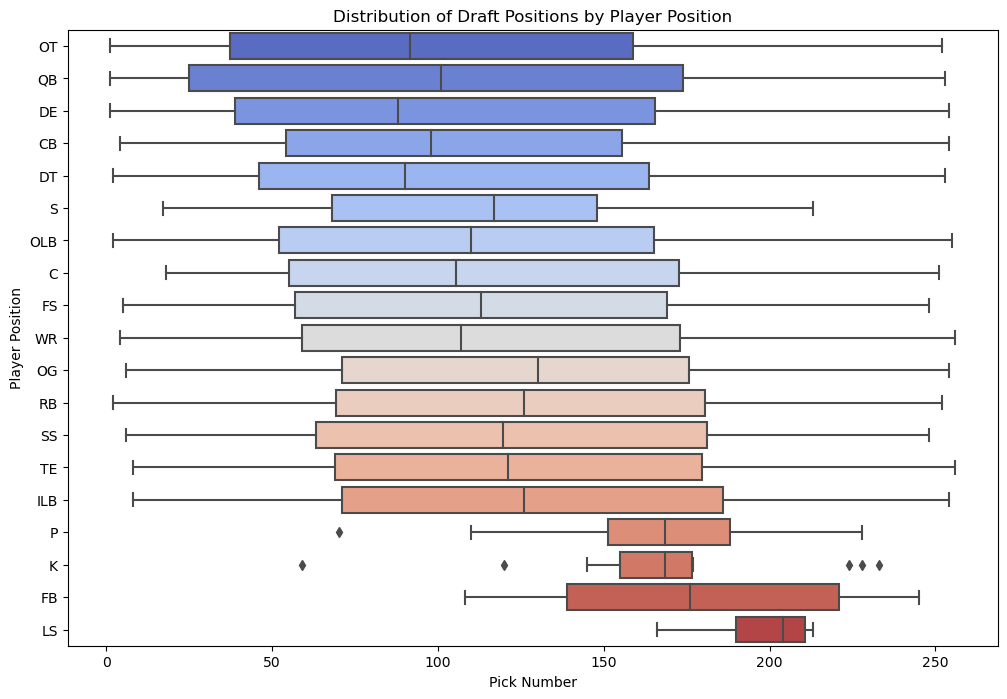

(                mean  median
 Position                    
 OT        102.352632    91.5
 QB        104.675214   101.0
 DE        106.088889    88.0
 CB        107.093525    98.0
 DT        107.896739    90.0
 S         111.344828   117.0
 OLB       112.192090   110.0
 C         114.870370   105.5
 FS        115.384615   113.0
 WR        115.735786   107.0
 OG        122.926230   130.0
 RB        124.541237   126.0
 SS        125.500000   119.5
 TE        126.859259   121.0
 ILB       128.656250   126.0
 P         166.833333   168.5
 K         167.857143   168.5
 FB        181.320000   176.0
 LS        196.750000   204.0,
 None)

In [3]:
# Calculate mean and median draft positions for each player position

position_draft_stats = combine.groupby('Position')['PickNumber'].agg(['mean', 'median']).sort_values(by='mean')

plt.figure(figsize=(12, 8))
# Visualize the distribution of draft positions for each player position
sns.boxplot(x='PickNumber', y='Position', data=combine, order=position_draft_stats.index, palette="coolwarm")
#Add appropriate labels to the plot
plt.title('Distribution of Draft Positions by Player Position')
plt.xlabel('Pick Number')
plt.ylabel('Player Position')

# Show mean and median draft position statistics and the plot
position_draft_stats, plt.show()


### Visuals

To begin our anaylsis into the impact combine performance has on draft position. First, lets compare the correlations independently.

In [4]:
correlation_matrix = combine[['Age', 'BMI', 'PickNumber', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Shuttle', 'Agility_3cone']].corr(method='pearson')
#Use pearsion correlation for each column with draft position and create a matrix
correlations_with_pick_number = correlation_matrix.loc['PickNumber'].drop('PickNumber')
#Drop the PickNumber column since we don't want to correlate it with itself
correlations_with_pick_number

Age                 0.228077
BMI                -0.031746
Sprint_40yd         0.068641
Vertical_Jump      -0.105332
Bench_Press_Reps   -0.080816
Broad_Jump         -0.118649
Shuttle             0.042885
Agility_3cone       0.031975
Name: PickNumber, dtype: float64

#### Performence Metric Bar
After finding the pearson correlation coefficent for all the combine metrics above we decided to display them in a way that we would be able to compare them easily. We chose to do this with a horizontal bar plot with each performence metric having its own bar.

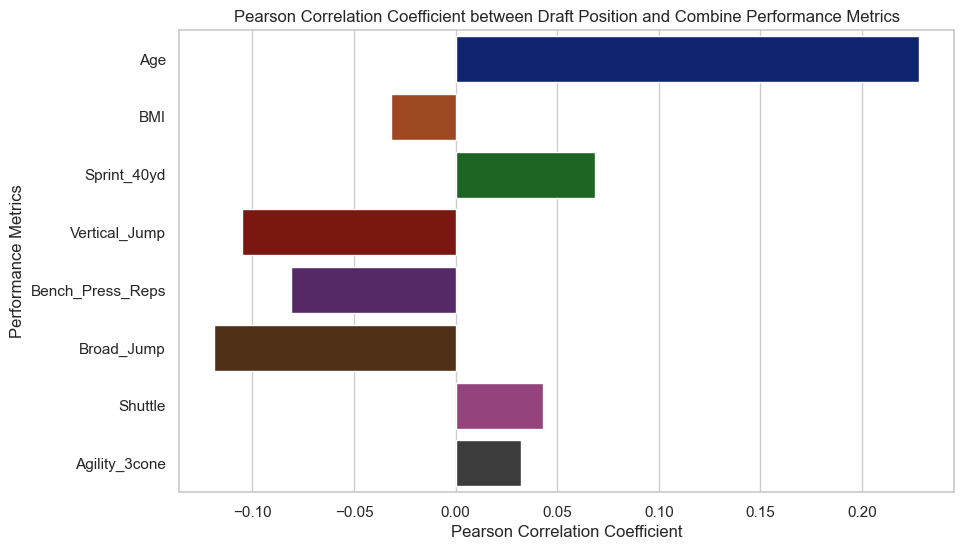

In [5]:
#Set style
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
correlation_values = correlations_with_pick_number.values
metrics = correlations_with_pick_number.index
sns.barplot(x=correlation_values, y=metrics, palette="dark")
#Label plot accordingly
plt.title('Pearson Correlation Coefficient between Draft Position and Combine Performance Metrics')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Performance Metrics')

plt.show()

As you can see by the graph above, Age is most correlated with draft position by a long shot. However, it has a correlation coefficient of around .2. Thus, we can assume that combine metrics are not correlated with draft position. Next, we will formally test whether combine metrics impact draft position by performing a mulitple linear regression.

#### Does the combine predict draft position?

We will expand upon our findings of each metric and its correlation to draft pick by running a multiple linear regression model. This will give us insight into which combine metrics explain the variability in PickNumber. As before, the metrics we will be looking at are: Age, Sprint_40, Vertical_Jump, Bench_Press_Reps, Broad_Jump, Agility_3cone, Shuttle, and BMI. 

In [6]:
X = combine[['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'BMI']]
Y = combine.PickNumber

# multiple linear regression model with summary table
mod = smf.ols('Y ~ X', data=combine)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     16.04
Date:                Wed, 24 Apr 2024   Prob (F-statistic):           1.23e-22
Time:                        22:48:28   Log-Likelihood:                -6611.1
No. Observations:                1179   AIC:                         1.324e+04
Df Residuals:                    1170   BIC:                         1.329e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -140.6737    113.425     -1.240      0.2

Based on the output table of the multiple linear regression, the full model is as follows: 

$$
PickNumber = -140.6737 + 16.8157*Age + 39.8830*Sprint\_40 -.0436*Vertical\_Jump -.6333*Bench\_Press\_Reps - \\ .5052*Braod\_Jump + 6.3640*Agility\_3cone - 2.8547*Shuttle - 5.3504*BMI
$$

Close inspection of the coefficents shows that this model makes sense. For instance, it makes sense that a slower 40 yard dash would yield a lower draft pick, hence the positive coefficent. Also, a higher vertical jump would yield a higher draft pick, hence the negative coefficient. Now, let's examine the R^2 value. With an R^2 of .099, combine metrics account for 9.3% of the variability in draft position, an abysmal result. Thus, we can not use this model to predict a players draft position based on our six metrics. From this, it is clear that a players performance does not have a significant impact on their draft position. This is an interesting result, given that metrics such as Age, Sprint_40, Braod_Jump, and BMI are clearly accounting for some variability in draft position, indicative of their significant p-values.

#### Custom combine metric to explain draft position
This result is somewhat expected, as combine performance is not measured by individual metrics, but rather a compiled score. Therefore, we decided to created our own metric to reduce combine performance to a single number. We did this by computing a weighted average of the scores from the eight metrics, applying greater weights to the four categories with the greatest correlation. The following table computes our custom metric, and ranks players by this metric, hoping to give insight into where the top performing prospects were drafted.

In [7]:
# custom metric ranked with player and draft position
custom = combine.copy()

scaled_columns1 = ['Age', 'Vertical_Jump', 'Broad_Jump']
scaled_columns2 = ['BMI', 'Sprint_40yd', 'Shuttle', 'Agility_3cone', 'Bench_Press_Reps']

custom_metrics1 = custom[scaled_columns1].apply(lambda x: x * 0.25) # weighting higher correlated metrics more than those that are less correlated
custom_metrics2 = custom[scaled_columns2].apply(lambda x: x * 0.005)
# combining scaled metrics into one series
custom_metrics = custom_metrics1.select_dtypes(include=[np.number]).sum(axis=1) + custom_metrics2.select_dtypes(include=[np.number]).sum(axis=1)
metric_data = pd.DataFrame({'Year': combine.Year, 'Player': combine.Player, 'Custom_Metric': custom_metrics, 'PickNumber': combine.PickNumber})
metric_data = metric_data.sort_values('Custom_Metric', ascending=False) # ordering the data based on our custom_metric
metric_data.head()

,Year,Player,Custom_Metric,PickNumber
1350,2015,Byron Jones\JoneBy00,127.309523,27
2193,2019,Juan Thornhill\ThorJu00,123.491114,63
1884,2017,Obi Melifonwu\MeliOb00,123.218329,56
1396,2015,Chris Conley\ConlCh00,122.645287,76
2140,2019,Miles Boykin\BoykMi00,122.292695,93


Using this data, we can run a second linear regression model, using our custom metric as the independent varaible. Below is a scatterplot of the data.

In [8]:
X = metric_data[['Custom_Metric']]
Y = metric_data.PickNumber

# running simple linear regression model with custom metric as independent variable 
mod = smf.ols('Y ~ X', data=metric_data)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.188
Date:                Wed, 24 Apr 2024   Prob (F-statistic):             0.0743
Time:                        22:48:28   Log-Likelihood:                -12781.
No. Observations:                2253   AIC:                         2.557e+04
Df Residuals:                    2251   BIC:                         2.558e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    121.3553      3.615     33.571      0.0

Based on the output, the simple linear regression model is as follows:

$$
PickNumber = 121.3553 - 0.0715*Custom\_Metric
$$

With an R^2 value of 0.001, our custom metric accounts for 0.1% of the variability in draft position. As it turns out, this model performs much worse than our multiple linear regression model, further proving that combine performance does not impact a players draft position.

Why is this? Inuitively, you would think that if a prospect performs better at the combine, that should increase their draft stock. While a fair assumption, in reality this does not happen. Most prospects enter the combine with already an idea of when they will be drafted. The combine does not generally offer players a chance to increase their draft stock, rather it offers top prospects a chance to showcase their skill in front of NFL scouts and coaches. For example, looking at the data table named metric_data, the player with the second highest score of 123.491114, Juan Thornhill, was drafted 63rd, well into the second round. If combine performance truly was indicative of draft position, surley Thornhill would have been drafted higher. 

### Part 2: Stadium Attendance and Team Performance

For our secondary analysis, we will be looking at players that were drafted first overall, and analyze their impact on team performance and stadium attendance. First, let's look at the player's impact on stadium attendance.

We collected data from 2000-2019 with each teams attendance for each game of the season. The data was cleaned to only include average attendance of home games (as this will show us the biggest impcat in attendance after drafting the number 1 overall pick). Below is each teams average attendence for years 2000-2019.

In [9]:
# raw data
attendance_dirty = pd.read_csv('attendance.csv')
# make a copy of the data
attendance = attendance_dirty.copy()
# combine team and team_name column into one team
attendance.team = attendance.team + ' ' + attendance['team_name']
# drop unrelated columns
attendance = attendance.drop(['team_name', 'away','home','total'], axis=1)
# drop columns with no data
attendance = attendance.dropna(axis='rows')
# find mean attendance for all home games
attendance = attendance.groupby(['year','team'])['weekly_attendance'].mean().reset_index()
attendance = attendance.groupby(['year','team'])['weekly_attendance'].mean().reset_index()
# add column with team abbreviation
attendance['abrev'] = attendance['team'].str[:3].str.upper()
attendance.loc[attendance['team'] == 'Los Angeles Rams', 'abrev'] = 'LAR'
attendance.loc[attendance['team'] == 'San Diego Chargers', 'abrev'] = 'SDG'
attendance.loc[attendance['team'] == 'San Francisco 49ers', 'abrev'] = 'SFO'
attendance.loc[attendance['team'] == 'St. Louis Rams', 'abrev'] = 'STL'
# sort by year
attendance = attendance.sort_values('year')
attendance.head()

,year,team,weekly_attendance,abrev
0,2000,Arizona Cardinals,55870.3750,ARI
30,2000,Washington Redskins,73395.7500,WAS
29,2000,Tennessee Titans,68204.6250,TEN
28,2000,Tampa Bay Buccaneers,67545.5625,TAM
27,2000,St. Louis Rams,67585.5000,STL


Next, we gathered NFL draft data that inlcudes every single pick from 2000-2019. We cleaned this data to include only the first overall pick from each year, resulting in the data frame below.

In [10]:
# raw data
draft_dirty = pd.read_csv('NFLDraftHistory.csv')
# make copy of data
draft = draft_dirty.copy()
# only keep first overall draft pick
draft = draft[draft.pick == 1]
# rename 'season' to 'year'
draft = draft.rename(columns = {'season': 'year'})
draft = draft[(draft.year >= 2000) & (draft.year <= 2019)]
draft = draft[['year','team','pfr_player_name']]
draft['team'].sort_values().unique()
draft.head()

,year,team,pfr_player_name
2684,2000,CLE,Courtney Brown
2938,2001,ATL,Michael Vick
3184,2002,HOU,David Carr
3445,2003,CIN,Carson Palmer
3707,2004,SDG,Eli Manning


Now that we have data with stadium attendance and top overall draft pick for years 2000-2019, we can merge these two data frames on the basis of year and team name. This results in the following data frame, outlining the year, the team with the number one overall draft pick, who was selected, and stadium attendance for the year. 

In [11]:
draft_att = pd.merge(draft,attendance, left_on = ['year','team'], right_on = ['year','abrev'])
draft_att = draft_att.drop(['team_y','abrev'], axis=1)
draft_att = draft_att.rename(columns = {'team_x':'team'})
draft_att

,year,team,pfr_player_name,weekly_attendance
0,2000,CLE,Courtney Brown,66071.1875
1,2001,ATL,Michael Vick,57367.6250
2,2002,HOU,David Carr,66357.6250
3,2003,CIN,Carson Palmer,59099.5000
4,2004,SDG,Eli Manning,64231.5000
5,2005,SFO,Alex Smith,69567.0625
6,2006,HOU,Mario Williams,67902.6875
7,2007,OAK,JaMarcus Russell,64615.6250
8,2008,MIA,Jake Long,66747.8125
9,2009,DET,Matthew Stafford,58230.0625


We can ammend this data frame by adding a row for the previous years attendance, as well as a column for the difference. This will give us insight into how the first overall pick impacts stadium attendance, as well as individual players impacts on attendance.

In [12]:
prev_year_att = []
teams = draft_att.team
for i in range(0,20):
     if (i == 0) or (i == 2) or (i == 16):
         prev_year_att.append(0)
     else:
        year = draft_att.loc[i].year - 1
        att = attendance.loc[(attendance.year == year) & (attendance.abrev == draft_att.team[i])]['weekly_attendance']
        prev_year_att.append(att.iloc[0])

draft_att['prev_year_att'] = prev_year_att
draft_att['prev_year_att'][0] = 72616.75
draft_att['prev_year_att'][16] = 57018.25
draft_att['difference'] = draft_att['weekly_attendance'] - draft_att['prev_year_att']
draft_att = draft_att.iloc[:,[0,1,2,4,3,5]]
draft_att

C:\Users\micha\AppData\Local\Temp\ipykernel_28364\2306644741.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  draft_att['prev_year_att'][0] = 72616.75
C:\Users\micha\AppData\Local\Temp\ipykernel_28364\2306644741.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  draft_att['prev_year_att'][16] = 57018.25


,year,team,pfr_player_name,prev_year_att,weekly_attendance,difference
0,2000,CLE,Courtney Brown,72616.7500,66071.1875,-6545.5625
1,2001,ATL,Michael Vick,60286.1875,57367.6250,-2918.5625
2,2002,HOU,David Carr,0.0000,66357.6250,66357.6250
3,2003,CIN,Carson Palmer,58391.5625,59099.5000,707.9375
4,2004,SDG,Eli Manning,62329.4375,64231.5000,1902.0625
5,2005,SFO,Alex Smith,64060.9375,69567.0625,5506.1250
6,2006,HOU,Mario Williams,68433.6250,67902.6875,-530.9375
7,2007,OAK,JaMarcus Russell,64981.6250,64615.6250,-366.0000
8,2008,MIA,Jake Long,72185.0625,66747.8125,-5437.2500
9,2009,DET,Matthew Stafford,60652.8125,58230.0625,-2422.7500


It should be noted that the Houston Texans do not have attendance data pre-2002, as they were not an established team yet. Additionally, the Rams moved back to Los Angeles in 2016, thus attendance data from 2015 was taken from their previous stadium in St. Louis. Also, the data we collected began in 2000, thus attendance data for the Cleveland Browns in 1999 was obtained from the official NFL webiste.

### Analysis and Visuals
#### Does getting the first overall draft pick influence attendance?

Now that we have our final, cleaned data set, we can begin to visualize these data. Below is a bar graph that displays average stadium attendance with the respective player drafted. There are two bars per player, blue indicating the year before the player was drafted, and red indicating the year the player was drafted. The sequence of bars goes from 2000-2019 from left to right.

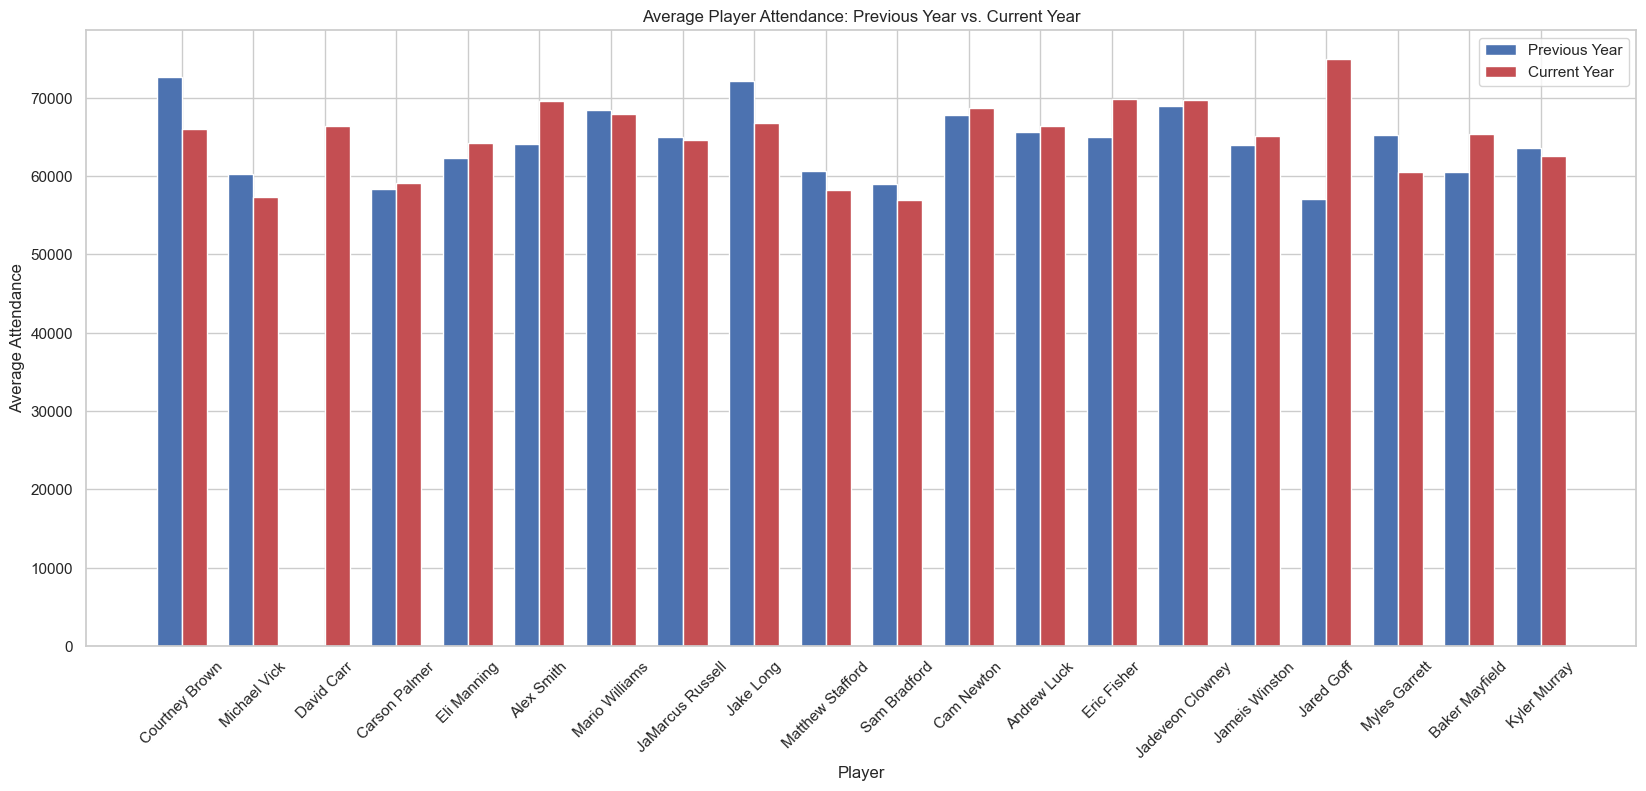

In [13]:
average_attendances = draft_att.groupby('team').agg({
    'prev_year_att': 'mean',
    'weekly_attendance': 'mean'
}).reset_index()
average_attendances['difference'] = average_attendances['weekly_attendance'] - average_attendances['prev_year_att']

plt.figure(figsize=(20, 8))

# Plotting data
x = range(len(draft_att))  # X-axis positions
width = 0.35  # Width of the bars

plt.bar(x, draft_att['prev_year_att'], width=width, label='Previous Year', color='b', align='center')
plt.bar([i + width for i in x], draft_att['weekly_attendance'], width=width, label='Current Year', color='r', align='center')

# Adding labels and title
plt.xlabel('Player')
plt.ylabel('Average Attendance')
plt.title('Average Player Attendance: Previous Year vs. Current Year')
plt.xticks([i + width/2 for i in x], draft_att['pfr_player_name'], rotation=45)  # Positioning team names in the middle of the grouped bars

# Adding a legend
plt.legend()

# Show plot
plt.show()

Based on the bar graph above, the player with the biggest impact in stadium attendance is unequivically Jared Goff, selected by the Los Angeles Rams. Other players that had notable impact on stadium attendance are Alex Smith, and Baker Mayfield. Overall, it appears that getting the first overall pick does not automatically guarantee a boost in attendance. Other factors such as offseason trades and trend in performance of the team all impact stadium attendance. Teams generally get the first overall pick when they have the worst record from the previous year, and so a team already in distress may not necessarily have a boost in attendance by getting one player. Jared Goff is an interesting exmaple. He was a hot prospect the year he was drafted, but he was also drafted the year the Rams moved back to LA, with a brand new stadium that exceeded the capacity of their previous stadium in St. Louis. Because of this, we can assume that the dramatic increase in attendance from 2015 to 2016 was due in part to the teams relocation. Additionally, notice David Carr, drafted by the Houston Texans, does not have attendance data for the year before he was drafted. This is because the Texans did not exist prior to 2002, thus anything related to attendance numbers can be assumed to be completely dominated by this fact.

<Axes: ylabel='team'>

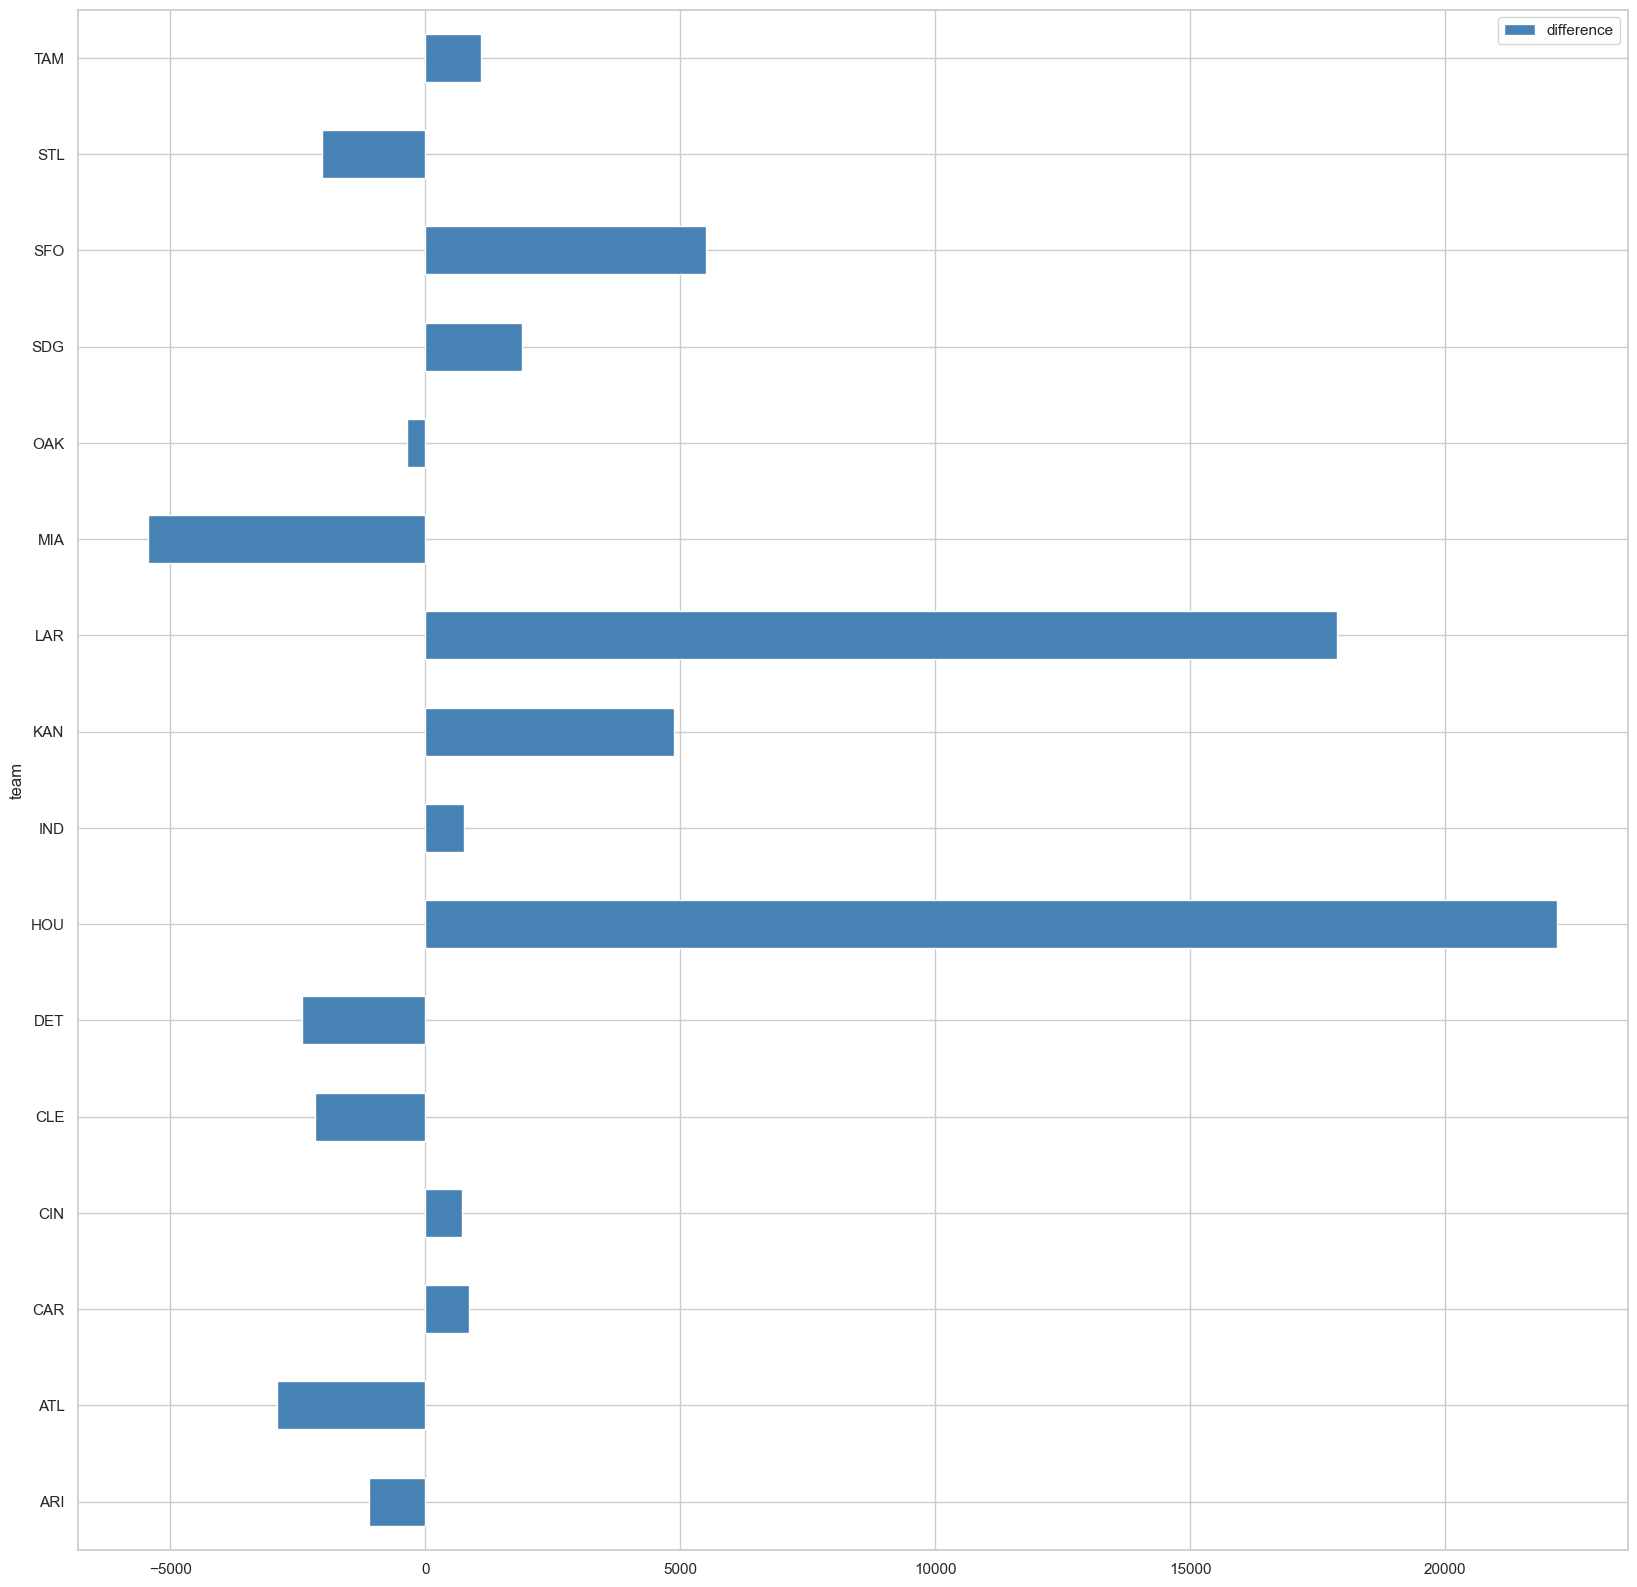

In [14]:
average_attendances.plot.barh(x='team', y='difference', figsize=(20,20), color='steelblue')

#### Caveat to our analysis
Furthermore, our analysis is looking at average attendance for the year in which each player was drafted. For further analysis, it may be interesting to focus on the home-opening game. The beginning of the season are when rookie prospects gain the most media attention. If the player exceeds expectations, interest in the player will continue throughout the season. It may be beneficial to see how number one overall draft picks influence attendance for their first home game as a rookie, rather than looking at all home games for the season.

#### What about team performance?

In [15]:
# raw data
stand = pd.read_csv('standings.csv') 
# filter out columns that are not needed
filtered_df = stand[['wins', 'year', 'team_name']]
# keep unique values
team_Names = stand.iloc[:,1].unique()
team_Names.sort()
# make the pivot table to be used in the widget
pivoted_df = filtered_df.pivot(index='team_name', columns='year', values='wins')
pivoted_df['team_name'] = sorted(team_Names)
pivoted_df

year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,team_name
team_name,,,,,,,,,,,,,,,,,,,,,
49ers,6.0,12.0,10.0,7.0,2.0,4.0,7.0,5.0,7.0,8.0,...,13.0,11.0,12.0,8.0,5.0,2.0,6.0,4.0,13.0,49ers
Bears,5.0,13.0,4.0,7.0,5.0,11.0,13.0,7.0,9.0,7.0,...,8.0,10.0,8.0,5.0,6.0,3.0,5.0,12.0,8.0,Bears
Bengals,4.0,6.0,2.0,8.0,8.0,11.0,8.0,7.0,4.0,10.0,...,9.0,10.0,11.0,10.0,12.0,6.0,7.0,6.0,2.0,Bengals
Bills,8.0,3.0,8.0,6.0,9.0,5.0,7.0,7.0,7.0,6.0,...,6.0,6.0,6.0,9.0,8.0,7.0,9.0,6.0,10.0,Bills
Broncos,11.0,8.0,9.0,10.0,10.0,13.0,9.0,7.0,8.0,8.0,...,8.0,13.0,13.0,12.0,12.0,9.0,5.0,6.0,7.0,Broncos
Browns,3.0,7.0,9.0,5.0,4.0,6.0,4.0,10.0,4.0,5.0,...,4.0,5.0,4.0,7.0,3.0,1.0,0.0,7.0,6.0,Browns
Buccaneers,10.0,9.0,12.0,7.0,5.0,11.0,4.0,9.0,9.0,3.0,...,4.0,7.0,4.0,2.0,6.0,9.0,5.0,5.0,7.0,Buccaneers
Cardinals,3.0,7.0,5.0,4.0,6.0,5.0,5.0,8.0,9.0,10.0,...,8.0,5.0,10.0,11.0,13.0,7.0,8.0,3.0,5.0,Cardinals
Chargers,1.0,5.0,8.0,4.0,12.0,9.0,14.0,11.0,8.0,13.0,...,8.0,7.0,9.0,9.0,4.0,5.0,9.0,12.0,5.0,Chargers


In [16]:
import ipywidgets as widgets
from IPython.display import display

# Load the standings data
stand = pd.read_csv("standings.csv")
filtered_df = stand[['wins', 'year', 'team_name']]
pivoted_df = filtered_df.pivot(index='team_name', columns='year', values='wins')

# Years are now column headers
years = [col for col in pivoted_df.columns if pd.api.types.is_numeric_dtype(pivoted_df[col])]

# Create a function to update the table based on the selected year
def update_table(year):
    sorted_df = pivoted_df[[year]].sort_values(by=year, ascending=False)
    sorted_df.columns = ['Wins']  # Rename the column to wins
    display(sorted_df)

# Create a slider widget for selecting years
year_slider = widgets.IntSlider(
    value=min(years),
    min=min(years),
    max=max(years),
    step=1,
    description='Year:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

widgets.interactive(update_table, year=year_slider)

interactive(children=(IntSlider(value=2000, continuous_update=False, description='Year:', max=2019, min=2000),…

Using ideas and concepts that we learned in class, we decided to use a widget in order to display each teams record by year. When it is first ran, each teams record will be displayed for the year 2000, since that is the earliest year in the data frame. The column will be sorted in decreasing order by number of wins. We can then use the slider in order to select another year up to 2019, since this is the latest year in the data frame.      In relation to our analysis, the team that finishes with the worst record in the NFL in a season is granted the first overall pick in the upcoming draft, baring a trade or another rare circumstance. By being able to cycle through the years, we are able to see which team finished with the worst record one year and see how the first overall pick affected their record for the next year.                                                      
One example of a #1 overall pick who had a very big impact on their teams record was the Rams selection of Sam Bradford. In 2009 the Rams finished bottom of the NFL with only 1 win. The following season after selecting Sam Bradford with the #1 overall pick their win total jumped to 7 in 2010. On the opposite side of the spectrum, there are #1 overall picks that do not have a much of an impact as Sam Bradford did with the Rams. In 2016 the Cleveland Browns finished bottom of the NFL with only 1 win the entire season. In turn they were awarded the #1 overall selection in the 2017 NFL draft where they selected Myles Garret. The following season the Browns finished with an even worse record of 0-16, not winning a single game. 

### Procedure
In this final analysis process we wanted to produce visualization for how a teams performance and stadium attendance has been affected through the first overall draft pick. The initial part of our second procedure, we found some raw data for an approximate 20 year span of attendance to stadiums. While we were cleaning up this data we noticed that there were discrempanices in team name abbreviations. We adjusted them as such.

Following this we began to clean the raw data that we found for NFL draft picks. This data spanned 20 years as well, and the same 20 years as our attendance data. Next, we combined these two datas. We wanted to see he correlation on the top pick players, and how it affected attendance. We also needed to compare the player to the respective team they played for that year. In the data, we believe we had the right idea but we noticed it might be difficult to see the attendance difference if we did not create a column comparing the previous year and current years attendance differences to see the positive or negative impact of the individual players.

Once we had this data table, we noticed it is a little dry. There needed to be more visualization for it than just a bunch of tables and numerical values in those columns. Thus, we created a bar chart to show this information. In the bar chart, we dipicted the first round pick players and how their attendance changed the stadium count by having our frequency the stadium attendance of the previous and current years. There is one thing we noticed about this data that shocked the group. While evaluating the data we noticed in the data for David Carr, there was a current years attendance and not a previous year stadium attendance. This compelled the group to further research and investigate this outlier to deteremine what solution we can have for this data. There are 32 teams currently in the NFL and we had not considered that there might not be a team in existance for this data or these teams. We found that the team he played for that year, the Houstan Texans, had just been established that previous year but had no stadium. As such, there would be no data for it these teams in that previous years. Perhaps, there is a better solution than the one we went with, but we thought have 0 attendance could tell the reader a story. Could tell them it was a new stadium, or in a new location, or perhaps a brand new team. It was exciting to learn when this team was founded and how it has impacted our data.

Further analysis showed, that there was a drastic increase to certain stadium attendance. One example for this is Jared Goff when he started for the Los Angeles Rams. Our horizontal histogram shows the size of the difference in attendance for these teams per the player.

Finally, the last thing we produced, was a visualization for the team rankings for these years. We cleaned the raw data that showed the necessary information, but displayed it in their dataframe a little differently than we imagined. So we created a new dataframe where we had the names of the teams as index values. Then transferred the years column as the variable names itself. This allowed us to show the rankings for each team by year. This data table showed us exactly what we wanted to see on how these teams were represented at the year of the respective years. However, we believed this table was not visualy appealing enough so after further discussion from the team we decided to build a widget where we can show the respective years and shift them by year and reorangize the data to fit the rankings. This final visualization gives our project some interaction from the audiance. In order to see what team was ranked highest for what year, you would need to shift and move the slider along.

### Credits
#### Part 2
Michael Holman wrote the code and analysis for the multiple and simple linear regression models, providing insight into which metrics most explain variations in draft pick.

Joey Kozohar wrote the code to find the distribution of Draft Positions by Player Positions graph and the code to visualize the pearson correlation coefficent for each combine metric in a graph.

Jason Bruno Terceros helped with the data research and correctly selecting the dataset. Helped with organizing the document and formating for presentability.

Steven Bottone helped with cleaning the data, commenting/organizing code, and analysis.

#### Part 3
Michael Holman cleaned the attendance and draft data, creating the 'draft_att' data frame that was used to make analysis about the effects aquiring the number one draft pick has on stadium attendance.

Joey Kozohar cleaned the standings.csv file which created the pivoted_df data frame which was used for the slider widget. Along with Jason, wrote the code for the slider widget as well as the code for the bar chart in order to visualize attendance difference each team has

Jason Bruno Terceros helped with organizing the document and formating for presentability. Wrote down the procedural steps. Assisted in producing the widget code itself. Worked out on cleaning the data to correctly produce the widget with teammates.

Steven Bottone created the double bar plot showing the current vs. previous year attendance, as well as the bar plot showing the difference between those years.